In [21]:
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier

# Load dataset
df=pd.read_csv('../data/spotify.csv',na_values=['',' ','-'],encoding='latin')
display(df.info())
print(df.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   track_name            953 non-null    str    
 1   released_year         953 non-null    int64  
 2   in_spotify_playlists  953 non-null    int64  
 3   in_spotify_charts     951 non-null    float64
 4   streams               953 non-null    int64  
 5   in_apple_playlists    953 non-null    int64  
 6   in_apple_charts       951 non-null    float64
 7   bpm                   953 non-null    int64  
 8   mode                  953 non-null    str    
 9   energy                953 non-null    int64  
 10  instrumentalness      953 non-null    int64  
 11  liveness              953 non-null    int64  
 12  speechiness           953 non-null    int64  
dtypes: float64(2), int64(9), str(2)
memory usage: 96.9 KB


None

track_name              0
released_year           0
in_spotify_playlists    0
in_spotify_charts       2
streams                 0
in_apple_playlists      0
in_apple_charts         2
bpm                     0
mode                    0
energy                  0
instrumentalness        0
liveness                0
speechiness             0
dtype: int64


In [22]:
# The original target variable "streams" contains the number of streams.
# Since KNN is a classification algorithm, streams is  transformed into a binary variable.

# The 75th percentile is used as a threshold.
# Songs above this value are considered high-stream songs.

import numpy as np
q3=df['streams'].quantile(0.75)
df['HighStreams']=np.where(df['streams']>q3,1,0)

# Remove original streams variable because it is used to create the target
df.drop(columns=['streams'],inplace=True)

In [23]:
# Removing non-informative attributes.
df.drop(columns=['track_name'],inplace=True)

In [24]:
#Replace missing values with median
median_spot=df['in_spotify_charts'].median()
df['in_spotify_charts']=df['in_spotify_charts'].fillna(median_spot)

median_ap=df['in_apple_charts'].median()
df['in_apple_charts']=df['in_apple_charts'].fillna(median_ap)

In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 953 entries, 0 to 952
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   released_year         953 non-null    int64  
 1   in_spotify_playlists  953 non-null    int64  
 2   in_spotify_charts     953 non-null    float64
 3   in_apple_playlists    953 non-null    int64  
 4   in_apple_charts       953 non-null    float64
 5   bpm                   953 non-null    int64  
 6   mode                  953 non-null    str    
 7   energy                953 non-null    int64  
 8   instrumentalness      953 non-null    int64  
 9   liveness              953 non-null    int64  
 10  speechiness           953 non-null    int64  
 11  HighStreams           953 non-null    int64  
dtypes: float64(2), int64(9), str(1)
memory usage: 89.5 KB


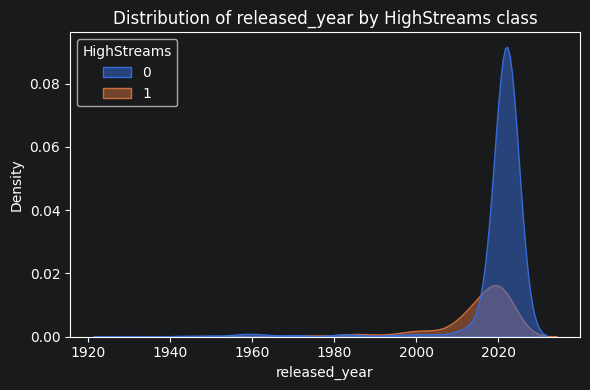

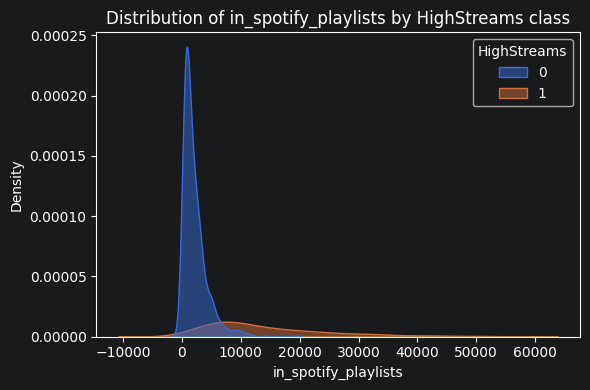

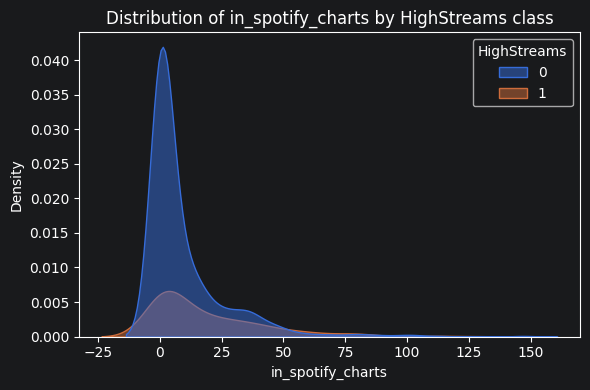

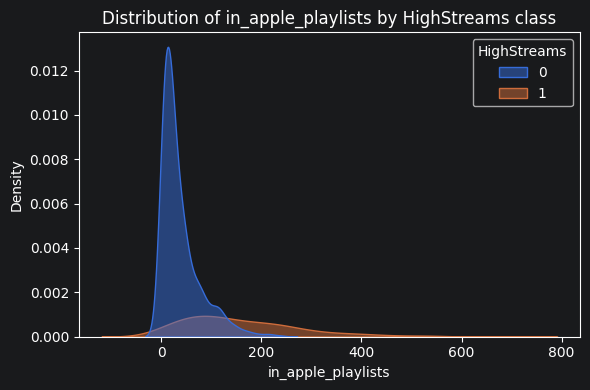

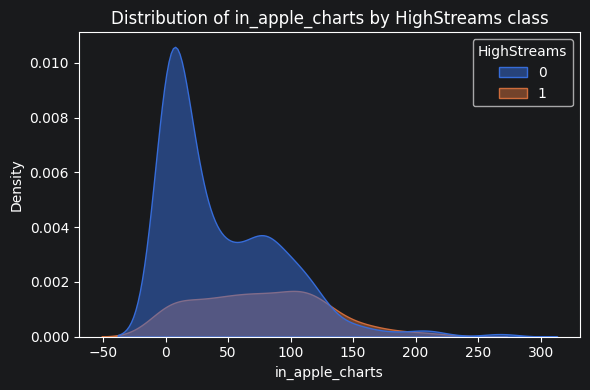

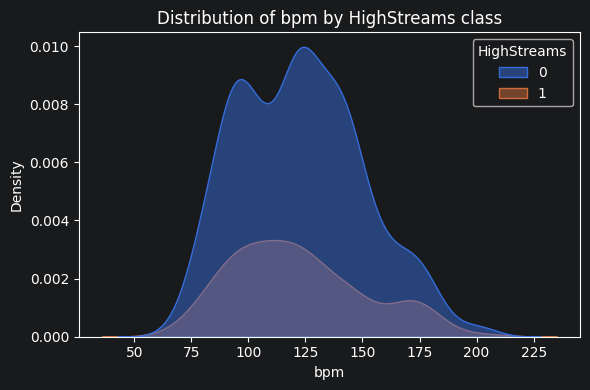

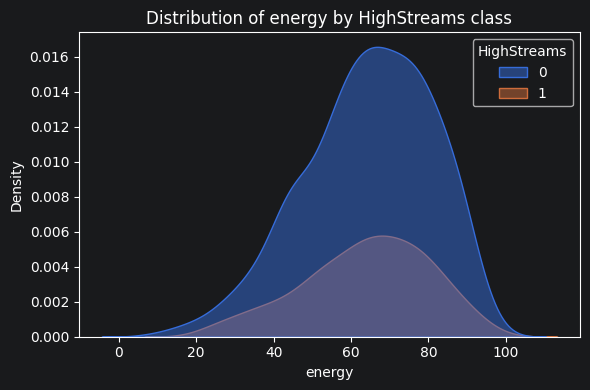

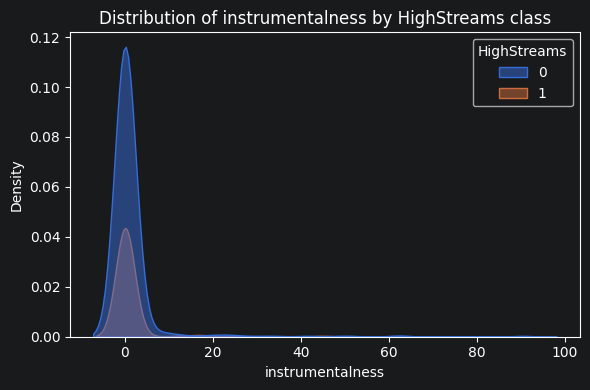

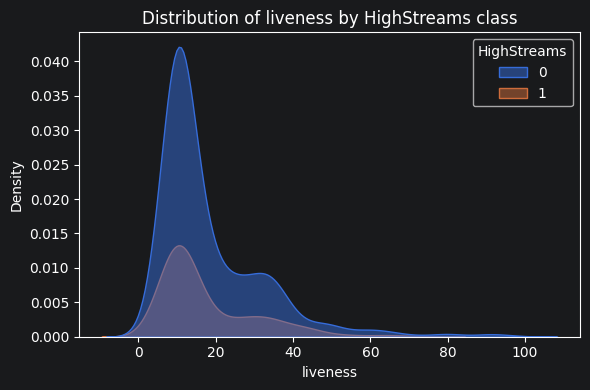

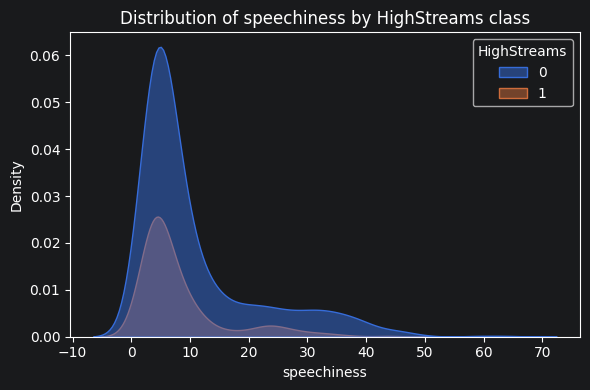

In [26]:
import matplotlib.pyplot as plt
import seaborn as sb

# Numerical variables used for distribution analysis
num_cols = [
    'released_year',
    'in_spotify_playlists',
    'in_spotify_charts',
    'in_apple_playlists',
    'in_apple_charts',
    'bpm',
    'energy',
    'instrumentalness',
    'liveness',
    'speechiness'
]
# KDE plots are used to compare the distribution
# of each variable between the two classes of the target variable.

for col in num_cols:

    plt.figure(figsize=(6,4))
    sb.kdeplot(data=df,x=col,hue='HighStreams',fill=True,alpha=0.5)
    plt.title(f'Distribution of {col} by HighStreams class')
    plt.tight_layout()
    plt.show()


In [27]:
# Variables whose distributions are very similar between both classes
# do not provide useful information for separating the classes.
# Therefore, they are removed from the dataset.
df.drop(columns=['speechiness','liveness','instrumentalness','energy'],inplace=True)

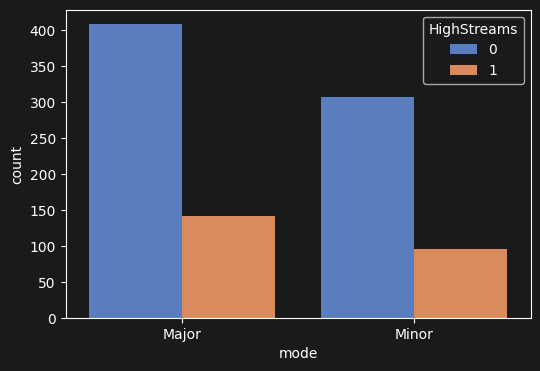

In [28]:
plt.figure(figsize=(6,4))
sb.countplot(df,x='mode',hue='HighStreams',palette='muted')
plt.show()


In [29]:
#Transform mode into a numerical values
df['mode']=df['mode'].map({'Major':0,'Minor':1})

In [30]:
#Counting outliers, KNN is sensitive to outliers because it is a distance-based algorithm.
def count_outliers(var):
    q1=var.quantile(0.25)
    q3=var.quantile(0.75)
    iqr=q3-q1
    lower=q1-1.5*iqr
    upper=q3+1.5*iqr

    return ((var<lower)|(var>upper)).sum()

In [32]:
numeric_cols=['released_year','in_spotify_playlists','in_spotify_charts','in_apple_playlists','in_apple_charts','bpm']
for col in numeric_cols:
    ouliers_per_col=count_outliers(df[col])
    print(col,ouliers_per_col)

from scipy.stats import shapiro

for col in numeric_cols:
    series=df[col]
    stat,p=shapiro(series)
    print(f'{col} {p:.5f}')

from sklearn.preprocessing import RobustScaler

# Since the dataset contains outliers, the distribution of numerical features is checked before scaling.
# As the features do not follow a normal distribution and contain extreme values,
# RobustScaler is used because it scales the data using the median and the interquartile range (IQR), making it less sensitive to outliers.

released_year 151
in_spotify_playlists 109
in_spotify_charts 76
in_apple_playlists 78
in_apple_charts 12
bpm 5
released_year 0.00000
in_spotify_playlists 0.00000
in_spotify_charts 0.00000
in_apple_playlists 0.00000
in_apple_charts 0.00000
bpm 0.00000


In [33]:
scaler=RobustScaler()
df_scaled=pd.DataFrame(scaler.fit_transform(df),columns=df.columns,index=df.index)

In [34]:
X=df_scaled.drop(columns='HighStreams')
y=df_scaled['HighStreams']

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)

In [35]:
from sklearn.model_selection import GridSearchCV,StratifiedKFold
from sklearn.neighbors import KNeighborsClassifier
cv=StratifiedKFold(n_splits=10,shuffle=True,random_state=42)
param_grid={'n_neighbors':list(range(3,26,2))}
knn=KNeighborsClassifier()
grid=GridSearchCV(knn,
                  cv=cv,
                  param_grid=param_grid,
                  scoring='accuracy',
                  verbose=1,
                  n_jobs=-1)
grid.fit(X_train,y_train)

# KNN performance depends on the choice of the number of neighbors.
# GridSearchCV is used to find the optimal value of K.
# StratifiedKFold is applied to preserve the proportion of classes in each validation fold.

Fitting 10 folds for each of 12 candidates, totalling 120 fits


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'n_neighbors': [3, 5, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : th

In [36]:
best_k=grid.best_params_['n_neighbors']
print(best_k)
# The final KNN model is trained using the optimal number of neighbors
knn=KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train,y_train)

7


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",7
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [37]:
y_pred=knn.predict(X_test)

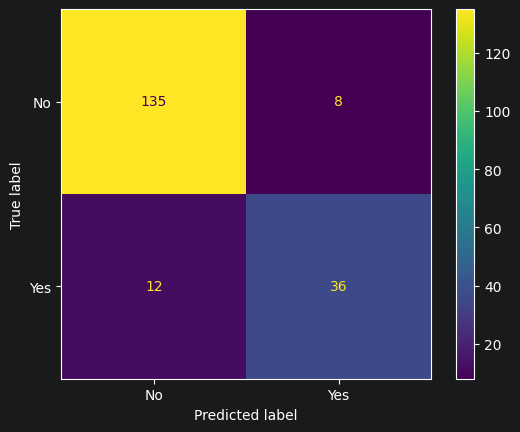

In [38]:
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,f1_score,recall_score,ConfusionMatrixDisplay

cm=confusion_matrix(y_test,y_pred)
disp=ConfusionMatrixDisplay(cm,display_labels=['No','Yes'])
disp.plot()
plt.show()

In [41]:
#True Positive (TP) – 36 songs were correctly predicted as having a high number of streams, and they actually have a high number of streams.
#True Negative (TN) – 135 songs were correctly predicted as not having a high number of streams, and they actually do not have a high number of streams.
#False Positive (FP) – 8 songs were predicted as having a high number of streams, but they actually do not have a high number of streams.
#False Negative (FN) – 12 songs were predicted as not having a high number of streams, but they actually have a high number of streams.

In [39]:
def compute_metrics(y_true,y_pred):
    accuracy=accuracy_score(y_true,y_pred)
    precision=precision_score(y_true,y_pred)
    recall=recall_score(y_true,y_pred)
    f1=f1_score(y_true,y_pred)

    return {
        'accuracy':accuracy,
        'precision':precision,
        'recall':recall,
        'f1':f1,
    }

metrics=compute_metrics(y_test,y_pred)
print(metrics)

{'accuracy': 0.8952879581151832, 'precision': 0.8181818181818182, 'recall': 0.75, 'f1': 0.782608695652174}


In [40]:
# Accuracy – 89.53% of songs were correctly classified, meaning that the model
# successfully predicted whether a song has a high number of streams or not.

# Precision – among all songs predicted as having a high number of streams,
# 82% actually have a high number of streams.

# Recall – among all songs that truly have a high number of streams,
# the model correctly identified 75% of them.

# F1 score – this metric represents a balance between precision and recall.
# In this case, the F1 score is 0.78, which indicates that the model achieves
# a good balance between detecting songs with a high number of streams and
# avoiding incorrect predictions of high-stream songs.